<a href="https://colab.research.google.com/github/riya-rajbhut/music-ai/blob/main/basic-neural-network/rnn_basic_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt install -y fluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fluidsynth is already the newest version (2.2.5-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
!pip install --upgrade pyfluidsynth

In [ ]:
!pip install pretty_midi

In [ ]:
import collections
import datetime
import fluidsynth
import glob
import numpy as np
import pathlib
import pandas as pd
import pretty_midi
import seaborn as sns
import tensorflow as tf

from IPython import display
from matplotlib import pyplot as plt
from typing import Optional

In [ ]:
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Sampling rate for audio playback
_SAMPLING_RATE = 16000

In [2]:
import pathlib
import tensorflow as tf

# 1. Download and extract the file, capturing the returned path to the zip file
zip_path = tf.keras.utils.get_file(
    'maestro-v3.0.0-midi.zip',
    origin='https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip',
    extract=True,
    cache_dir='.', cache_subdir='data',
)

# 2. Point to the actual extracted folder inside 'data/'
# Keras extracts the archive contents directly into 'data/', which contains the 'maestro-v3.0.0' folder




58416533/58416533 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
#!dir /s data
#!ls -R data/
import pathlib

# 1. Update this to the actual folder path shown in your file listing
data_dir = pathlib.Path('data/maestro-v3_extracted/maestro-v3.0.0')

# 2. Fix the glob pattern to look recursively (**/) through the subfolders
filenames = list(data_dir.glob('**/*.mid*'))

print('Number of files found:', len(filenames))

Number of files found: 1276


# Process a MIDI file
First, use pretty_midi to parse a single MIDI file and inspect the format of the notes.

In [5]:
sample_file = filenames[1]
print(sample_file)

data/maestro-v3_extracted/maestro-v3.0.0/2009/MIDI-Unprocessed_08_R1_2009_01-04_ORIG_MID--AUDIO_08_R1_2009_08_R1_2009_02_WAV.midi


In [ ]:
#Generate a PrettyMIDI object for the sample MIDI file.
pm = pretty_midi.PrettyMIDI(sample_file)

# Why is it hanging?
By default, pm.fluidsynth() synthesizes the entire MIDI file before your code extracts the 30-second snippet (waveform[:seconds*_SAMPLING_RATE]). If your MIDI file is long (e.g., a 10-minute classical piece), generating CD-quality audio at 44.1 kHz takes a massive amount of processing power and memory, forcing your notebook kernel to grind to a halt.

# The Fix:
Trim the MIDI before synthesizing it
Instead of synthesizing the whole file and cutting the audio down, cut the MIDI file to 30 seconds first. This way, FluidSynth only has to process 30 seconds of data, which takes less than a second to execute.

In [ ]:
def display_audio(pm: pretty_midi.PrettyMIDI, seconds=30):
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  # Take a sample of the generated waveform to mitigate kernel resets
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  # Force Jupyter to display the returned audio player
  return display(display_audio(pm, seconds=30))

#display_audio(pm, seconds=30) #this func is hanging coz its synthecising entire file first (which is taking time) and then cutting for first 30 secs

In [ ]:
import copy
import pretty_midi
from IPython import display

def display_audio(pm: pretty_midi.PrettyMIDI, seconds=30):
    # 1. Deep copy the MIDI object so we don't alter the original file
    pm_short = copy.deepcopy(pm)

    # 2. Trim the MIDI data down to the requested duration
    # This prevents fluidsynth from rendering minutes of silent or heavy audio
    pm_short.adjust_times([0, seconds], [0, seconds])

    # 3. Cut off any notes trailing past the limit
    for instrument in pm_short.instruments:
        instrument.notes = [n for n in instrument.notes if n.start < seconds]
        for n in instrument.notes:
            if n.end > seconds:
                n.end = seconds

    # 4. Synthesize only the 30-second chunk
    waveform_short = pm_short.fluidsynth(fs=_SAMPLING_RATE)

    return display.Audio(waveform_short, rate=_SAMPLING_RATE)

# Call and explicitly display the player
# Change 'display(...)' to 'display.display(...)'
display.display(display_audio(pm, seconds=30))

In [ ]:
# What kind of Instruments are used??
print('Number of instruments:', len(pm.instruments))
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
print('Instrument name:', instrument_name)

Number of instruments: 1
Instrument name: Acoustic Grand Piano


In [ ]:
for i, note in enumerate(instrument.notes[:10]):
  note_name = pretty_midi.note_number_to_name(note.pitch)
  duration = note.end - note.start
  print(f'{i}: pitch={note.pitch}, note_name={note_name},'
        f' duration={duration:.4f}')

0: pitch=60, note_name=C4, duration=1.2357
1: pitch=48, note_name=C3, duration=1.2383
2: pitch=36, note_name=C2, duration=1.2357
3: pitch=55, note_name=G3, duration=1.2578
4: pitch=51, note_name=D#3, duration=1.2708
5: pitch=51, note_name=D#3, duration=0.0391
6: pitch=55, note_name=G3, duration=0.0365
7: pitch=60, note_name=C4, duration=0.0443
8: pitch=48, note_name=C3, duration=0.0456
9: pitch=36, note_name=C2, duration=0.0391


# Convert MidiToNotes
We will use three variables to represent a note when training the model: **pitch**, **step** and **duration**.
The **pitch** is the perceptual quality of the sound as a MIDI note number.
The **step** is the time elapsed from the previous note or start of the track.
The **duration** is how long the note will be playing in seconds and is the difference between the note end and note start times.

Extract the notes from the sample MIDI file.

In [ ]:
def midi_to_notes(midi_file: str) -> pd.DataFrame:
  pm = pretty_midi.PrettyMIDI(midi_file)
  # Now we will print raw midi file to view its contents
  print('MIDI file name:', midi_file)
  print

  instrument = pm.instruments[0]
  notes = collections.defaultdict(list)

  # Sort the notes by start time
  sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
  prev_start = sorted_notes[0].start

  for note in sorted_notes:
    start = note.start
    end = note.end
    notes['pitch'].append(note.pitch)
    notes['start'].append(start)
    notes['end'].append(end)
    notes['step'].append(start - prev_start)
    notes['duration'].append(end - start)
    prev_start = start

  return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

In [ ]:
raw_notes = midi_to_notes(sample_file)
raw_notes.head()
# Print the raw list of note objects for the first instrument
print(pm.instruments[0].notes[:20])

[Note(start=0.639323, end=1.875000, pitch=60, velocity=83), Note(start=0.638021, end=1.876302, pitch=48, velocity=87), Note(start=0.644531, end=1.880208, pitch=36, velocity=85), Note(start=0.636719, end=1.894531, pitch=55, velocity=85), Note(start=0.638021, end=1.908854, pitch=51, velocity=88), Note(start=2.105469, end=2.144531, pitch=51, velocity=73), Note(start=2.117188, end=2.153646, pitch=55, velocity=66), Note(start=2.109375, end=2.153646, pitch=60, velocity=75), Note(start=2.117188, end=2.162760, pitch=48, velocity=89), Note(start=2.126302, end=2.165365, pitch=36, velocity=90), Note(start=2.229167, end=2.397135, pitch=53, velocity=100), Note(start=2.227865, end=2.404948, pitch=48, velocity=95), Note(start=2.226562, end=2.404948, pitch=56, velocity=94), Note(start=2.230469, end=2.404948, pitch=62, velocity=91), Note(start=2.233073, end=2.407552, pitch=36, velocity=97), Note(start=2.794271, end=2.920573, pitch=53, velocity=92), Note(start=2.791667, end=2.929688, pitch=62, velocity=

In [ ]:
get_note_names = np.vectorize(pretty_midi.note_number_to_name)
sample_note_names = get_note_names(raw_notes['pitch'])
sample_note_names[:10]

array(['G3', 'C3', 'D#3', 'C4', 'C2', 'D#3', 'C4', 'G3', 'C3', 'C2'],
      dtype='<U3')

To visualize the musical piece, plot the note pitch, start and end across the length of the track (i.e. piano roll). Start with the first 100 notes

In [ ]:
def plot_piano_roll(notes: pd.DataFrame, count: Optional[int] = None):
  if count:
    title = f'First {count} notes'
  else:
    title = f'Whole track'
    count = len(notes['pitch'])
  plt.figure(figsize=(20, 4))
  plot_pitch = np.stack([notes['pitch'], notes['pitch']], axis=0)
  plot_start_stop = np.stack([notes['start'], notes['end']], axis=0)
  plt.plot(
      plot_start_stop[:, :count], plot_pitch[:, :count], color="b", marker=".")
  plt.xlabel('Time [s]')
  plt.ylabel('Pitch')
  _ = plt.title(title)

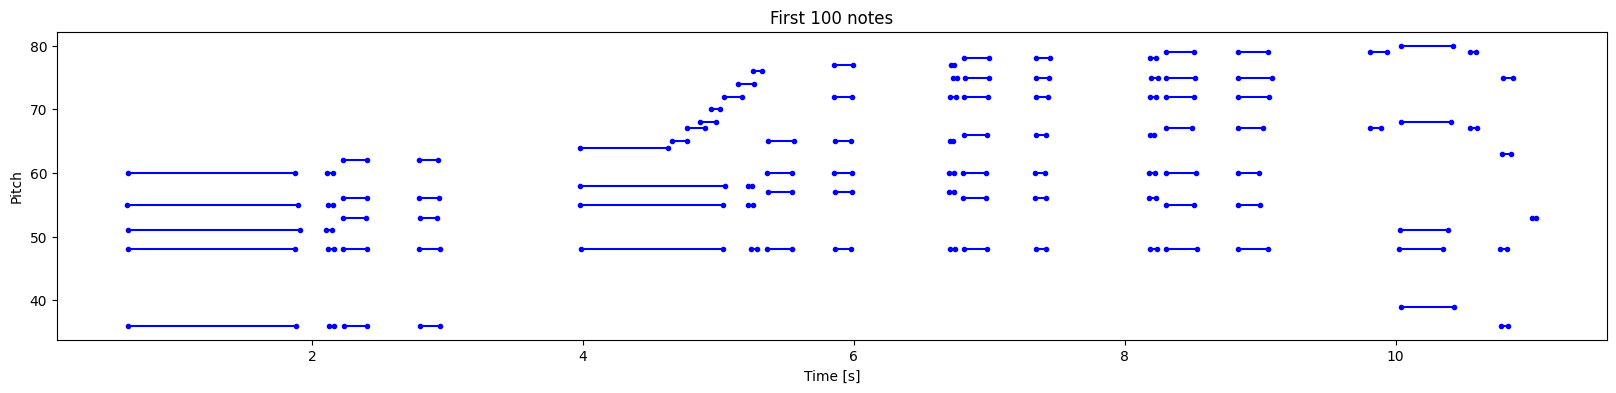

In [ ]:
plot_piano_roll(raw_notes, count=100)

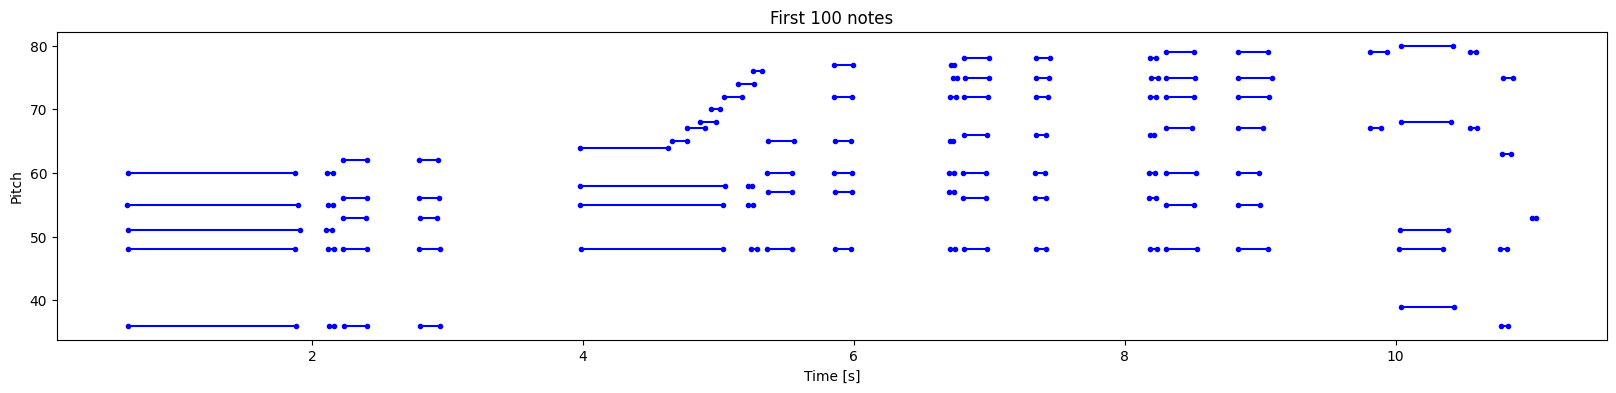

In [ ]:
plot_piano_roll(raw_notes, count=100)

Check the distribution of each note variable.

In [ ]:
def plot_distributions(notes: pd.DataFrame, drop_percentile=2.5):
  plt.figure(figsize=[15, 5])
  plt.subplot(1, 3, 1)
  sns.histplot(notes, x="pitch", bins=20)

  plt.subplot(1, 3, 2)
  max_step = np.percentile(notes['step'], 100 - drop_percentile)
  sns.histplot(notes, x="step", bins=np.linspace(0, max_step, 21))

  plt.subplot(1, 3, 3)
  max_duration = np.percentile(notes['duration'], 100 - drop_percentile)
  sns.histplot(notes, x="duration", bins=np.linspace(0, max_duration, 21))

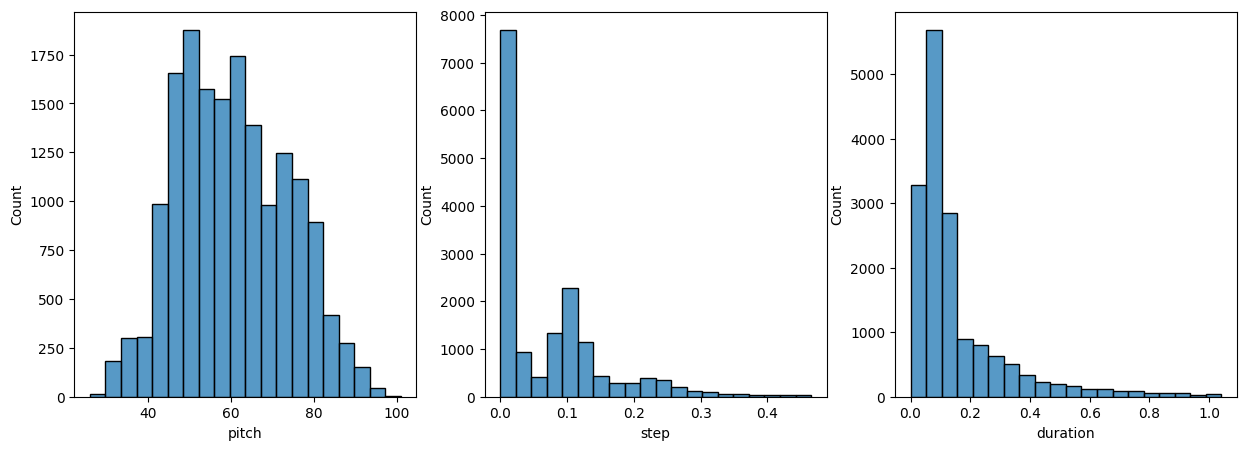

In [ ]:
plot_distributions(raw_notes)

Now,let's try to recreate the music from the Midi file using existing data. We will try to play it ourselves.

In [ ]:
def notes_to_midi_using_existing_data(
  notes: pd.DataFrame,
  out_file: str,
  instrument_name: str,
  velocity: int = 100,  # note loudness
) -> pretty_midi.PrettyMIDI:

  pm = pretty_midi.PrettyMIDI()
  instrument = pretty_midi.Instrument(
      program=pretty_midi.instrument_name_to_program(
          instrument_name))

  prev_start = 0
  for i, note in notes.iterrows():
    start = float(prev_start + note['step'])
    end = float(start + note['duration'])
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=int(note['pitch']),
        start=start,
        end=end,
    )
    instrument.notes.append(note)
    prev_start = start

  pm.instruments.append(instrument)
  pm.write(out_file)
  return pm

In [ ]:
example_file = 'example.midi'
example_pm = notes_to_midi_using_existing_data(
    raw_notes, out_file=example_file, instrument_name=instrument_name)

In [ ]:
display_audio(example_pm)

Now,let's try to recreate the music from Midi format human readable string given in the cell itself. We will try to play it ourselves.

In [ ]:
import pretty_midi

def notes_to_midi_using_text(
    notes_text: str,
    out_file: str,
    instrument_name: str,
    velocity: int = 100,  # note loudness
) -> pretty_midi.PrettyMIDI:

    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program(instrument_name)
    )

    prev_start = 0

    # Split the string by lines and iterate
    for line in notes_text.strip().split('\n'):
        # Skip empty lines or comments if any
        if not line.strip() or line.strip().startswith('#'):
            continue

        # Parse the space-separated values
        pitch_str, step_str, duration_str = line.split()

        start = float(prev_start + float(step_str))
        end = float(start + float(duration_str))

        note = pretty_midi.Note(
            velocity=velocity,
            pitch=int(pitch_str),
            start=start,
            end=end,
        )
        instrument.notes.append(note)
        prev_start = start

    pm.instruments.append(instrument)
    pm.write(out_file)
    return pm

In [ ]:
# Sample text: "pitch step duration"
# 60 = Middle C, 64 = E, 67 = G, 72 = High C
sample_music_text = """
55 0.0 0.5
64 0.5 0.5
67 0.5 0.5
72 0.5 1.0
"""

# Generate the MIDI file
pm_object = notes_to_midi_using_text(
    notes_text=sample_music_text,
    out_file='output.mid',
    instrument_name='Acoustic Grand Piano',
    velocity=100
)

print("MIDI file generated successfully!")

MIDI file generated successfully!


In [ ]:
display_audio(pm_object)